In [45]:
import os
os.listdir("./")

['.ipynb_checkpoints',
 '01 Điểm pinball cho q10 q90.txt',
 '02 Giải thích ý nghĩa từng chỉ số .txt',
 '03 Phần tiếp theo.txt',
 'Coverage lý tưởng .txt',
 'Cách đánh giá loss.txt',
 'evaluate.ipynb',
 'New Text Document.txt',
 'Nâng cấp sau khi evaluate .txt',
 'predictions_result.csv',
 'Đọc thêm']

In [46]:
import pandas as pd
model_train_result= pd.read_csv(r'C:\Users\trieu\OneDrive\Desktop\Dự án\01 Của tôi\PJ1\data\processed\model_train_result.csv', index_col=0)
model_test_result= pd.read_csv(r'C:\Users\trieu\OneDrive\Desktop\Dự án\01 Của tôi\PJ1\data\processed\model_test_result.csv', index_col=0)
y_train = model_train_result.y_train
pred_q50_train = model_train_result.pred_q50_train
pred_q50_train = model_train_result.pred_q50_train
pred_q10_train = model_train_result.pred_q10_train
pred_q90_train = model_train_result.pred_q90_train

In [47]:
model_test_result
y_test = model_test_result.y_test
pred_q50_test = model_test_result.pred_q50_test
pred_q50_test = model_test_result.pred_q50_test
pred_q10_test = model_test_result.pred_q10_test
pred_q90_test = model_test_result.pred_q90_test

In [48]:
# Coverage - % y thật rơi vào
# Width - vùng y thật rơi vào
# Train
import numpy as np
# Coverage train (debug / check overfit)
cover10_90_train = np.mean((y_train >= pred_q10_train) & (y_train <= pred_q90_train))
cover10_50_train = np.mean((y_train >= pred_q10_train) & (y_train <= pred_q50_train))
cover50_90_train = np.mean((y_train >= pred_q50_train) & (y_train <= pred_q90_train))

cover10_train = np.mean(y_train <= pred_q10_train)
cover50_train = np.mean(y_train <= pred_q50_train)
cover90_train = np.mean(y_train <= pred_q90_train)

# Coverage trên test (evaluate chính thức)
cover10_90_test = np.mean((y_test >= pred_q10_test) & (y_test <= pred_q90_test))
cover10_50_test = np.mean((y_test >= pred_q10_test) & (y_test <= pred_q50_test))
cover50_90_test = np.mean((y_test >= pred_q50_test) & (y_test <= pred_q90_test))

cover10_test = np.mean(y_test <= pred_q10_test)
cover50_test = np.mean(y_test <= pred_q50_test)
cover90_test = np.mean(y_test <= pred_q90_test)

# Interval width (train & test)
width_train = pred_q90_train - pred_q10_train
width_test  = pred_q90_test - pred_q10_test

print("Train coverage 10-90:", cover10_90_train, "Width mean:", width_train.mean())
print("Test coverage 10-90:", cover10_90_test, "Width mean:", width_test.mean())
print("Width mean gap:",width_train.mean()-width_test.mean())
print("\nTest coverage 10:", cover10_test, "Train coverage 10:", cover10_train)
print("Test coverage 50:", cover50_test, "Train coverage 50:", cover50_train)
print("Test coverage 90:", cover90_test, "Train coverage 90:", cover90_train)

# Check test-train, test-expextation
# Cao hơn là overfit, thấp hơn là underfit

Train coverage 10-90: 0.8039390088945362 Width mean: 100188.79863024835
Test coverage 10-90: 0.7733163913595934 Width mean: 100639.70006530994
Width mean gap: -450.90143506159075

Test coverage 10: 0.11512071156289708 Train coverage 10: 0.0980304955527319
Test coverage 50: 0.5123252858958068 Train coverage 50: 0.501143583227446
Test coverage 90: 0.8881829733163914 Train coverage 90: 0.9019695044472681


In [5]:
# công thức pin ball = MSError= |y-y^| nhân với a
# Tính pinball_loss
# import numpy as np
# def pinball_loss(y,y_pred,alpha):
#     diff = y- y_pred
#     return np.mean(np.maximum(alpha*diff,(alpha-1)*diff)) # maximum không phải max

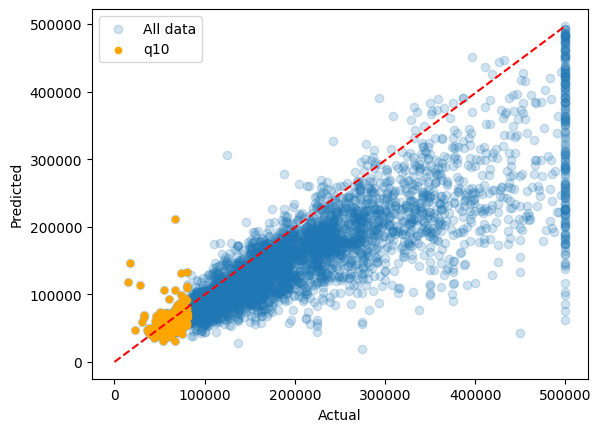

In [14]:
import numpy as np
import matplotlib.pyplot as plt

mask_q10 = y_test <= y_test.quantile(0.1)

plt.scatter(y_test, pred_q10_test, alpha=0.2, label='All data')

plt.scatter(y_test[mask_q10], pred_q10_test[mask_q10], color='orange', label='q10', s=20)
plt.plot([0, max(y_test)], [0, max(pred_q10_test)], 'r--')
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [41]:
bias = (y_test - pred_q50_test).mean()
pred_q50_test = pred_q50_test + bias

In [43]:
(y_test - pred_q50_test).mean()

np.float64(-1.97409702710403e-12)

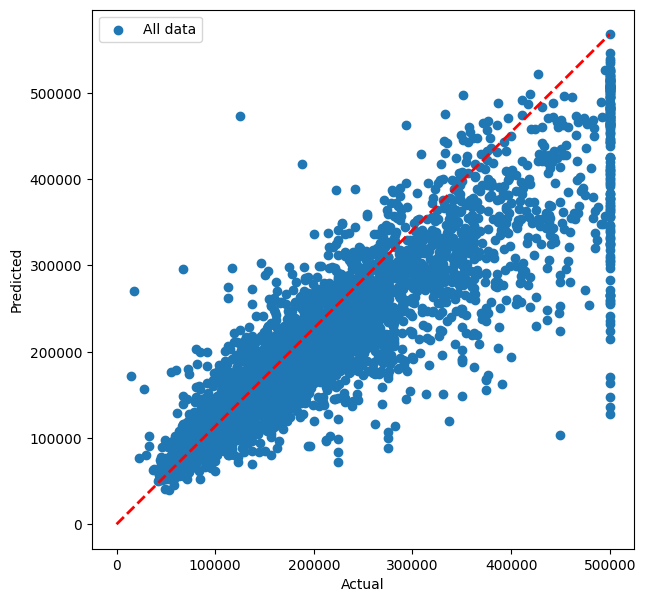

In [44]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred_q50_test, label='All data')

plt.plot([0, max(y_test)], [0, max(pred_q50_test)], 'r--', lw=2)
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

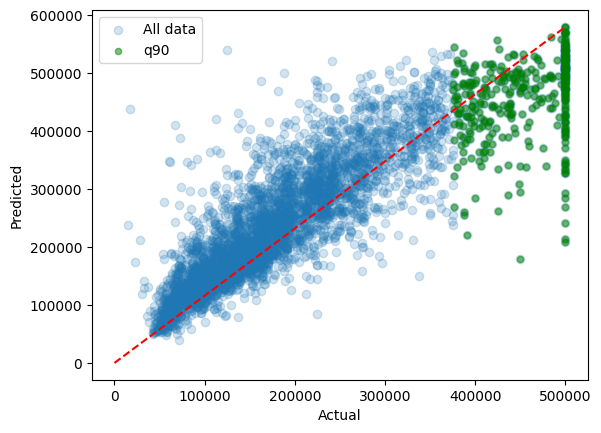

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo mask 10% nhỏ nhất
mask_q90 = y_test >= y_test.quantile(0.9)

plt.scatter(y_test, pred_q90_test, alpha=0.2, label='All data')
plt.scatter(y_test[mask_q90], pred_q90_test[mask_q90],alpha=0.5, color='green', label='q90', s=20)

plt.plot([0, max(y_test)], [0, max(pred_q90_test)], 'r--')
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [38]:
def interval_score(y, l, u, alpha=0.2):
    return np.mean(
        (u - l) +
        (2/alpha)*(l - y)*(y < l) +
        (2/alpha)*(y - u)*(y > u)
    )

interval_score(y_test, pred10, pred90)

NameError: name 'pred10' is not defined

In [19]:
# Check quantile crossing
np.mean(pred10 <= pred50), np.mean(pred50 <= pred90)

NameError: name 'pred10' is not defined